# AIO activation

This notebook reproduces Figure 2, Tables 3–5, and the activation results in §4.1 directly from the released raw records. It does not use a precomputed analysis table.

**Definition.** An execution returns an AIO when its raw `result.json` has `aioExists = true`. Activation rate is `AIO executions / query executions × 100`.

## Build the query-level table from raw results

In [1]:
from pathlib import Path
import json
import re
import unicodedata

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.stats import chi2_contingency, pearsonr, spearmanr

# Support running from either the repository root or replication/.
ROOT = Path.cwd()
if not (ROOT / "raw" / "query_results").is_dir():
    ROOT = ROOT.parent

RAW_QUERIES = ROOT / "raw" / "query_results"
RAW_AIOS = ROOT / "raw" / "aio_results"
OBSERVATIONS_CSV = ROOT / "replication" / "observations.csv"

QUESTION_WORDS = {
    "who", "what", "where", "when", "why", "how", "which",
    "is", "are", "was", "can", "do", "does", "did", "has",
}

CATEGORY_NAMES = {
    "autos_vehicles": "Autos & Vehicles",
    "beauty_fashion": "Beauty & Fashion",
    "business_finance": "Business & Finance",
    "climate": "Climate",
    "entertainment": "Entertainment",
    "food_drink": "Food & Drink",
    "games": "Games",
    "health": "Health",
    "hobbies_leisure": "Hobbies & Leisure",
    "jobs_education": "Jobs & Education",
    "law_gov": "Law & Gov.",
    "other": "Other",
    "pets_animals": "Pets & Animals",
    "politics": "Politics",
    "science": "Science",
    "shopping": "Shopping",
    "sports": "Sports",
    "technology": "Technology",
    "travel_transport": "Travel & Transport",
}

def path_fields(path, raw_root):
    """Read collection date and category from the two leading folders."""
    day_folder, category_folder = path.relative_to(raw_root).parts[:2]
    date = re.search(r"(\d{4}-\d{2}-\d{2})T", day_folder).group(1)
    slug = re.match(r"trending_US_1d_(.+?)_\d{4}-", category_folder).group(1)
    return date, CATEGORY_NAMES[slug]

def normalize_query(query):
    normalized = unicodedata.normalize("NFKC", query).casefold()
    return " ".join(normalized.split())

def show_table(frame, formats=None):
    """Format selected columns and display a table without a row index."""
    output = frame.copy()
    for column, template in (formats or {}).items():
        output[column] = output[column].map(template.format)
    display(HTML(output.to_html(index=False, border=0)))

rows = []
for path in sorted(RAW_QUERIES.rglob("result.json")):
    record = json.loads(path.read_text(encoding="utf-8"))
    date, category = path_fields(path, RAW_QUERIES)
    query = record.get("keyword") or record.get("searchKeyword") or ""
    first_word = query.casefold().strip().split(maxsplit=1)[0] if query.strip() else ""
    rows.append({
        "date": date,
        "category": category,
        "query": query,
        "timestamp": record.get("timestamp", ""),
        "aio": int(bool(record.get("aioExists"))),
        "question_type": first_word if first_word in QUESTION_WORDS else "",
        "word_count": len(query.split()),
        "normalized_query": normalize_query(query),
        "is_captcha": int(bool(record.get("isCaptchaPage"))),
        "is_search_result": int(bool(record.get("isSearchResultPage", True))),
    })

observations = pd.DataFrame(rows).sort_values(
    ["date", "category", "timestamp", "query"], kind="stable"
).reset_index(drop=True)

# These checks define the activation cohort used in the paper.
assert len(observations) == 55_393
assert observations["date"].nunique() == 40
assert observations["category"].nunique() == 19
assert observations["is_captcha"].sum() == 0
assert observations["is_search_result"].eq(1).all()
assert observations["aio"].sum() == 7_583

OBSERVATIONS_CSV.parent.mkdir(exist_ok=True)
observations.to_csv(OBSERVATIONS_CSV, index=False)
print(f"Generated {OBSERVATIONS_CSV.relative_to(ROOT)} from {len(observations):,} raw result files.")

Generated replication/observations.csv from 55,393 raw result files.


## Study population

In [2]:
start = observations["date"].min()
end = observations["date"].max()
n_queries = len(observations)
n_aios = int(observations["aio"].sum())
activation_rate = 100 * n_aios / n_queries

assert (start, end) == ("2026-03-13", "2026-04-21")
assert round(activation_rate, 1) == 13.7

overview = pd.DataFrame([{
    "Observation window": f"{start} to {end}",
    "Days": observations["date"].nunique(),
    "Categories": observations["category"].nunique(),
    "Queries": n_queries,
    "AIOs": n_aios,
    "Activation rate": activation_rate,
}])
show_table(overview, {
    "Queries": "{:,}", "AIOs": "{:,}", "Activation rate": "{:.1f}%"
})

Observation window,Days,Categories,Queries,AIOs,Activation rate
2026-03-13 to 2026-04-21,40,19,"55,393","7,583",13.7%


## Figure 2 — Daily AIO activation

The daily rate is `daily AIOs / daily queries × 100`. The moving average uses the current day and up to six preceding days.

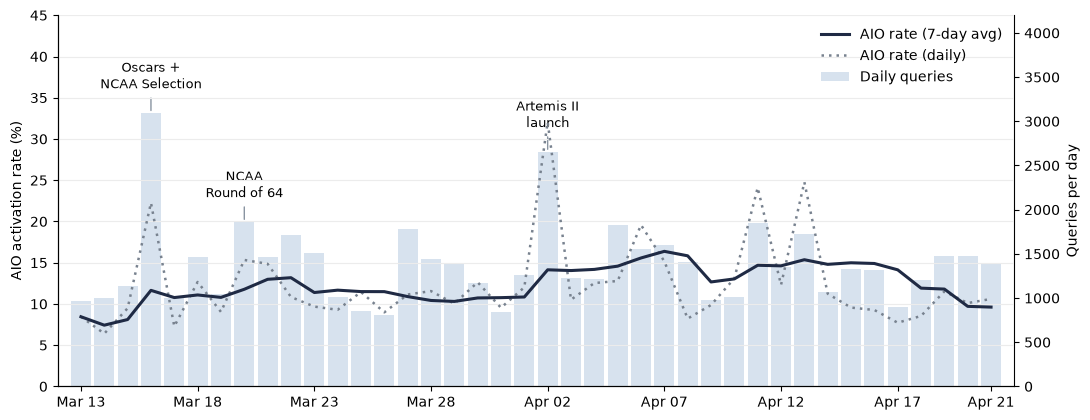

Date,Queries,× daily mean,AIO rate
2026-03-16,"3,091",2.2×,22.3%
2026-04-02,"2,652",1.9×,32.1%
2026-03-20,"1,859",1.3×,15.3%


In [3]:
daily = (
    observations.groupby("date", as_index=False)
    .agg(Queries=("aio", "size"), AIOs=("aio", "sum"))
)
daily["date"] = pd.to_datetime(daily["date"])
daily["AIO rate"] = 100 * daily["AIOs"] / daily["Queries"]
daily["7-day average"] = daily["AIO rate"].rolling(7, min_periods=1).mean()

top_days = daily.nlargest(3, "Queries").copy()
top_days["× daily mean"] = top_days["Queries"] / daily["Queries"].mean()

assert top_days["date"].dt.strftime("%Y-%m-%d").tolist() == [
    "2026-03-16", "2026-04-02", "2026-03-20"
]
assert top_days["× daily mean"].round(1).tolist() == [2.2, 1.9, 1.3]
rates_by_date = daily.set_index(daily["date"].dt.strftime("%Y-%m-%d"))["AIO rate"]
assert round(rates_by_date["2026-03-16"], 1) == 22.3
assert round(rates_by_date["2026-04-02"], 1) == 32.1

fig, rate_ax = plt.subplots(figsize=(11, 4.3))
volume_ax = rate_ax.twinx()

volume_ax.bar(
    daily["date"], daily["Queries"], width=0.85,
    color="#d7e2ee", edgecolor="none", label="Daily queries", zorder=1,
)
rate_ax.plot(
    daily["date"], daily["AIO rate"], color="#78828f",
    linestyle=(0, (1, 2)), linewidth=1.8, label="AIO rate (daily)", zorder=3,
)
rate_ax.plot(
    daily["date"], daily["7-day average"], color="#1f2a44",
    linewidth=2.2, label="AIO rate (7-day avg)", zorder=4,
)

event_labels = {
    "2026-03-16": "Oscars +\nNCAA Selection",
    "2026-03-20": "NCAA\nRound of 64",
    "2026-04-02": "Artemis II\nlaunch",
}
for date, label in event_labels.items():
    row = daily.loc[daily["date"] == pd.Timestamp(date)].iloc[0]
    volume_ax.annotate(
        label, xy=(row["date"], row["Queries"]), xytext=(0, 18),
        textcoords="offset points", ha="center", fontsize=9,
        arrowprops={"arrowstyle": "-", "color": "#8994a1"},
    )

rate_ax.set_ylabel("AIO activation rate (%)")
volume_ax.set_ylabel("Queries per day")
rate_ax.set_xlabel("")
rate_ax.set_ylim(0, 45)
volume_ax.set_ylim(0, 4_200)
tick_dates = daily.iloc[[0, 5, 10, 15, 20, 25, 30, 35, 39]]["date"]
rate_ax.set_xticks(tick_dates)
rate_ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
rate_ax.set_xlim(daily["date"].min() - pd.Timedelta(days=1),
                 daily["date"].max() + pd.Timedelta(days=1))
rate_ax.grid(axis="y", color="#ececec")
rate_ax.spines[["top", "right"]].set_visible(False)
volume_ax.spines["top"].set_visible(False)
rate_ax.set_zorder(volume_ax.get_zorder() + 1)
rate_ax.patch.set_visible(False)

handles_1, labels_1 = rate_ax.get_legend_handles_labels()
handles_2, labels_2 = volume_ax.get_legend_handles_labels()
rate_ax.legend(
    [handles_1[1], handles_1[0], *handles_2],
    [labels_1[1], labels_1[0], *labels_2],
    frameon=False, loc="upper right",
)
fig.tight_layout()
plt.show()

event_days = top_days.assign(Date=top_days["date"].dt.strftime("%Y-%m-%d"))[
    ["Date", "Queries", "× daily mean", "AIO rate"]
]
show_table(event_days, {
    "Queries": "{:,}", "× daily mean": "{:.1f}×", "AIO rate": "{:.1f}%"
})

## Table 3 — Activation by category

For each category, activation rate is `AIOs / Queries × 100`; corpus share is `Queries / 55,393 × 100`.

In [4]:
category_table = (
    observations.groupby("category")
    .agg(Queries=("aio", "size"), AIOs=("aio", "sum"))
)
category_table["Rate"] = 100 * category_table["AIOs"] / category_table["Queries"]
category_table["% of corpus"] = 100 * category_table["Queries"] / len(observations)
category_table = category_table.sort_values("Queries", ascending=False)

expected_category_counts = {
    "Sports": (28_446, 2_782), "Entertainment": (8_251, 1_348),
    "Business & Finance": (3_360, 880), "Other": (2_957, 405),
    "Law & Gov.": (2_924, 280), "Politics": (2_166, 162),
    "Climate": (1_735, 128), "Science": (1_560, 622),
    "Hobbies & Leisure": (1_185, 546), "Games": (778, 80),
    "Technology": (464, 86), "Food & Drink": (289, 71),
    "Health": (278, 74), "Travel & Transport": (265, 23),
    "Jobs & Education": (252, 43), "Shopping": (158, 23),
    "Beauty & Fashion": (142, 5), "Autos & Vehicles": (138, 19),
    "Pets & Animals": (45, 6),
}
actual_category_counts = {
    category: (int(row.Queries), int(row.AIOs))
    for category, row in category_table.iterrows()
}
assert actual_category_counts == expected_category_counts

table3 = category_table.reset_index(names="Category")
table3.loc[len(table3)] = ["Total", n_queries, n_aios, activation_rate, 100.0]
show_table(table3, {
    "Queries": "{:,}", "AIOs": "{:,}", "Rate": "{:.1f}%", "% of corpus": "{:.1f}%"
})

Category,Queries,AIOs,Rate,% of corpus
Sports,"28,446","2,782",9.8%,51.4%
Entertainment,"8,251","1,348",16.3%,14.9%
Business & Finance,"3,360",880,26.2%,6.1%
Other,"2,957",405,13.7%,5.3%
Law & Gov.,"2,924",280,9.6%,5.3%
Politics,"2,166",162,7.5%,3.9%
Climate,"1,735",128,7.4%,3.1%
Science,"1,560",622,39.9%,2.8%
Hobbies & Leisure,"1,185",546,46.1%,2.1%
Games,778,80,10.3%,1.4%


## Table 4 — Activation by leading interrogative

A query is a question when its first complete word is one of the 15 interrogatives defined in the paper.

In [5]:
question_rows = observations[observations["question_type"] != ""]
interrogatives = (
    question_rows.groupby("question_type")
    .agg(AIOs=("aio", "sum"), Queries=("aio", "size"))
)
interrogatives["Rate"] = 100 * interrogatives["AIOs"] / interrogatives["Queries"]
interrogatives = interrogatives.sort_values(["Rate", "Queries"], ascending=[False, False])

expected_interrogative_counts = {
    "does": (12, 12), "which": (2, 2), "do": (1, 1), "can": (34, 35),
    "how": (451, 535), "has": (70, 87), "why": (102, 139),
    "when": (313, 431), "are": (49, 72), "where": (715, 1_092),
    "what": (402, 663), "is": (296, 533), "was": (16, 32),
    "who": (169, 353), "did": (84, 211),
}
actual_interrogative_counts = {
    word: (int(row.AIOs), int(row.Queries))
    for word, row in interrogatives.iterrows()
}
assert actual_interrogative_counts == expected_interrogative_counts

question_totals = pd.DataFrame([
    {"Interrogative": "All questions", "AIOs": int(question_rows["aio"].sum()),
     "Queries": len(question_rows)},
    {"Interrogative": "All non-questions", "AIOs": int((observations["question_type"] == "").mul(observations["aio"]).sum()),
     "Queries": int((observations["question_type"] == "").sum())},
])
question_totals["Rate"] = 100 * question_totals["AIOs"] / question_totals["Queries"]
assert question_totals[["AIOs", "Queries"]].values.tolist() == [[2_716, 4_198], [4_867, 51_195]]

table4 = pd.concat([
    interrogatives.reset_index(names="Interrogative"), question_totals
], ignore_index=True)
show_table(table4, {
    "AIOs": "{:,}", "Queries": "{:,}", "Rate": "{:.1f}%"
})

question_rate, non_question_rate = question_totals["Rate"]
rate_ratio = question_rate / non_question_rate
display(Markdown(
    f"Question queries activate at **{question_rate:.1f}%**, compared with "
    f"**{non_question_rate:.1f}%** for non-questions: **{rate_ratio:.1f}×** as often."
))

Interrogative,AIOs,Queries,Rate
does,12,12,100.0%
which,2,2,100.0%
do,1,1,100.0%
can,34,35,97.1%
how,451,535,84.3%
has,70,87,80.5%
why,102,139,73.4%
when,313,431,72.6%
are,49,72,68.1%
where,715,"1,092",65.5%


Question queries activate at **64.7%**, compared with **9.5%** for non-questions: **6.8×** as often.

## Table 5 — Activation by query length

Word count uses whitespace-separated tokens. Six or more words are combined into one group.

In [6]:
length_order = ["1", "2", "3", "4", "5", "6+"]
observations["length_group"] = observations["word_count"].clip(upper=6).astype(str)
observations.loc[observations["word_count"] >= 6, "length_group"] = "6+"

def summarize_lengths(frame, prefix):
    result = frame.groupby("length_group").agg(
        **{f"{prefix} N": ("aio", "size"), f"{prefix} AIOs": ("aio", "sum")}
    ).reindex(length_order)
    result[f"{prefix} Rate"] = 100 * result[f"{prefix} AIOs"] / result[f"{prefix} N"]
    return result

all_lengths = summarize_lengths(observations, "All")
non_question_lengths = summarize_lengths(
    observations[observations["question_type"] == ""], "Non-question"
)
table5 = all_lengths.join(non_question_lengths).reset_index(names="Words")

expected_all = [(5_949, 593), (22_941, 782), (12_918, 1_678),
                (6_829, 1_368), (3_148, 1_066), (3_608, 2_096)]
expected_non_question = [(5_941, 589), (22_939, 781), (12_746, 1_600),
                         (6_305, 1_066), (2_139, 396), (1_125, 435)]
assert list(map(tuple, table5[["All N", "All AIOs"]].to_numpy())) == expected_all
assert list(map(tuple, table5[["Non-question N", "Non-question AIOs"]].to_numpy())) == expected_non_question

show_table(table5, {
    "All N": "{:,}", "All AIOs": "{:,}", "All Rate": "{:.1f}%",
    "Non-question N": "{:,}", "Non-question AIOs": "{:,}",
    "Non-question Rate": "{:.1f}%",
})

Words,All N,All AIOs,All Rate,Non-question N,Non-question AIOs,Non-question Rate
1,"5,949",593,10.0%,"5,941",589,9.9%
2,"22,941",782,3.4%,"22,939",781,3.4%
3,"12,918","1,678",13.0%,"12,746","1,600",12.6%
4,"6,829","1,368",20.0%,"6,305","1,066",16.9%
5,"3,148","1,066",33.9%,"2,139",396,18.5%
6+,"3,608","2,096",58.1%,"1,125",435,38.7%


## Statistical tests reported in §4.1

The activation–fidelity test below reads the final verification JSONs directly and defines category fidelity as `(Clear + Vague) / all verified claims`.

In [7]:
# Question-form vs. non-question activation.
q_aio, q_total = int(question_totals.loc[0, "AIOs"]), int(question_totals.loc[0, "Queries"])
nq_aio, nq_total = int(question_totals.loc[1, "AIOs"]), int(question_totals.loc[1, "Queries"])
chi2, chi_p, _, _ = chi2_contingency(
    [[q_aio, q_total - q_aio], [nq_aio, nq_total - nq_aio]], correction=False
)

# Category query volume vs. category activation.
volume_rho, volume_p = spearmanr(category_table["Queries"], category_table["Rate"])

# Category activation vs. category fidelity, calculated from raw verdict files.
label_rows = []
for path in sorted(RAW_AIOS.rglob("verification_result_grok-4-1-fast-reasoning_v2.json")):
    _, category = path_fields(path, RAW_AIOS)
    counts = json.loads(path.read_text(encoding="utf-8"))["label_counts"]
    label_rows.append({"category": category, **counts})

labels = pd.DataFrame(label_rows)
assert len(labels) == 7_491
label_totals = labels.groupby("category").sum(numeric_only=True)
label_totals["Fidelity"] = 100 * (
    label_totals["CLEAR"] + label_totals["VAGUE"]
) / label_totals.sum(axis=1)
assert int(label_totals[["CLEAR", "VAGUE", "AMBIGUOUS", "INCORRECT", "OMITTED"]].to_numpy().sum()) == 98_020

activation_and_fidelity = category_table[["Rate"]].join(label_totals[["Fidelity"]])
fidelity_r, fidelity_p = pearsonr(
    activation_and_fidelity["Rate"], activation_and_fidelity["Fidelity"]
)

assert round(chi2, 1) == 10_002.2 and chi_p < 0.001
assert round(volume_rho, 2) == 0.02 and round(volume_p, 2) == 0.93
assert round(fidelity_r, 3) == 0.313 and round(fidelity_p, 3) == 0.192

tests = pd.DataFrame([
    ["Question vs. non-question activation", "Pearson χ²", f"{chi2:,.1f}", "<0.001"],
    ["Category query volume vs. activation", "Spearman ρ", f"{volume_rho:.2f}", f"{volume_p:.2f}"],
    ["Category activation vs. fidelity", "Pearson r", f"{fidelity_r:.3f}", f"{fidelity_p:.3f}"],
], columns=["Comparison", "Test", "Statistic", "p-value"])
show_table(tests)

Comparison,Test,Statistic,p-value
Question vs. non-question activation,Pearson χ²,"10,002.2",<0.001
Category query volume vs. activation,Spearman ρ,0.02,0.93
Category activation vs. fidelity,Pearson r,0.313,0.192


## Repeated-query sensitivity

Each normalized query receives total weight one. Its contribution is therefore its mean activation across executions, and the balanced estimate is the mean across normalized queries.

In [8]:
baseline_rate = 100 * observations["aio"].mean()
balanced_rate = 100 * observations.groupby("normalized_query")["aio"].mean().mean()
difference = balanced_rate - baseline_rate

assert observations["normalized_query"].nunique() == 32_608
assert round(baseline_rate, 2) == 13.69
assert round(balanced_rate, 2) == 16.03
assert round(difference, 2) == 2.34

repeated_query_check = pd.DataFrame([{
    "Baseline activation": baseline_rate,
    "Query-balanced activation": balanced_rate,
    "Difference": difference,
}])
show_table(repeated_query_check, {
    "Baseline activation": "{:.2f}%",
    "Query-balanced activation": "{:.2f}%",
    "Difference": "+{:.2f} pp",
})

Baseline activation,Query-balanced activation,Difference
13.69%,16.03%,+2.34 pp
